In [1]:
import zarr
from pathlib import Path

import geopandas as gpd
import pandas as pd

import json
from pathlib import Path

import geopandas as gpd
import os

import matplotlib.pyplot as plt
import zipfile

import numpy as np
import copy

from scipy.io import FortranFile 


In [2]:
project_folder = ""

treemap_bulk_density = project_folder + 'data/treesrhof_adj.dat'
new_bulk_density = project_folder + 'data/quicfire_inputs_treemap/treesrhof.dat'

In [3]:

def read_dat_file(filename, nz, ny, nx, order= "C"):
    """
    Read in a .dat file as a numpy array.

    Parameters
    ----------
    filename : Path or str
        The path to the .dat file to read.
    nz : int
        The number of cells in the z-direction.
    ny : int
        The number of cells in the y-direction.
    nx : int
        The number of cells in the x-direction.
    order : str, optional
        The order of the array. Default is "C".

    Returns
    -------
    ndarray
        A 3D numpy array representing the data in the .dat file. The array
        has dimensions (nz, ny, nx).
    """
    if isinstance(filename, str):
        filename = (filename)

    with open(filename, "rb") as fin:
        arr = (
            FortranFile(fin)
            .read_reals(dtype="float32")
            .reshape((nz, ny, nx), order=order)
        )

    return arr

In [4]:
with open(project_folder + 'data/metadata.json', 'r') as json_file:
    metadata_adj = json.load(json_file)
    
nx_adj = metadata_adj['fire_grid']['nx']
ny_adj = metadata_adj['fire_grid']['ny']
nz_adj = metadata_adj['fire_grid']['nz']

with open(project_folder + 'data/quicfire_inputs_treemap/metadata.json', 'r') as json_file:
    metadata_tm = json.load(json_file)
    
nx_tm = metadata_tm['fire_grid']['nx']
ny_tm = metadata_tm['fire_grid']['ny']
nz_tm = metadata_tm['fire_grid']['nz']

In [5]:

new_bulk_density_path = project_folder + 'data/treesrhof.dat'
treemap_bulk_density_path = project_folder + 'data/quicfire_inputs_treemap/treesrhof.dat'

new_bulk_density = read_dat_file(new_bulk_density_path, nz_adj, ny_adj, nx_adj, order= "C")
treemap_bulk_density = read_dat_file(treemap_bulk_density_path, nz_tm, ny_tm, nx_tm, order= "C")

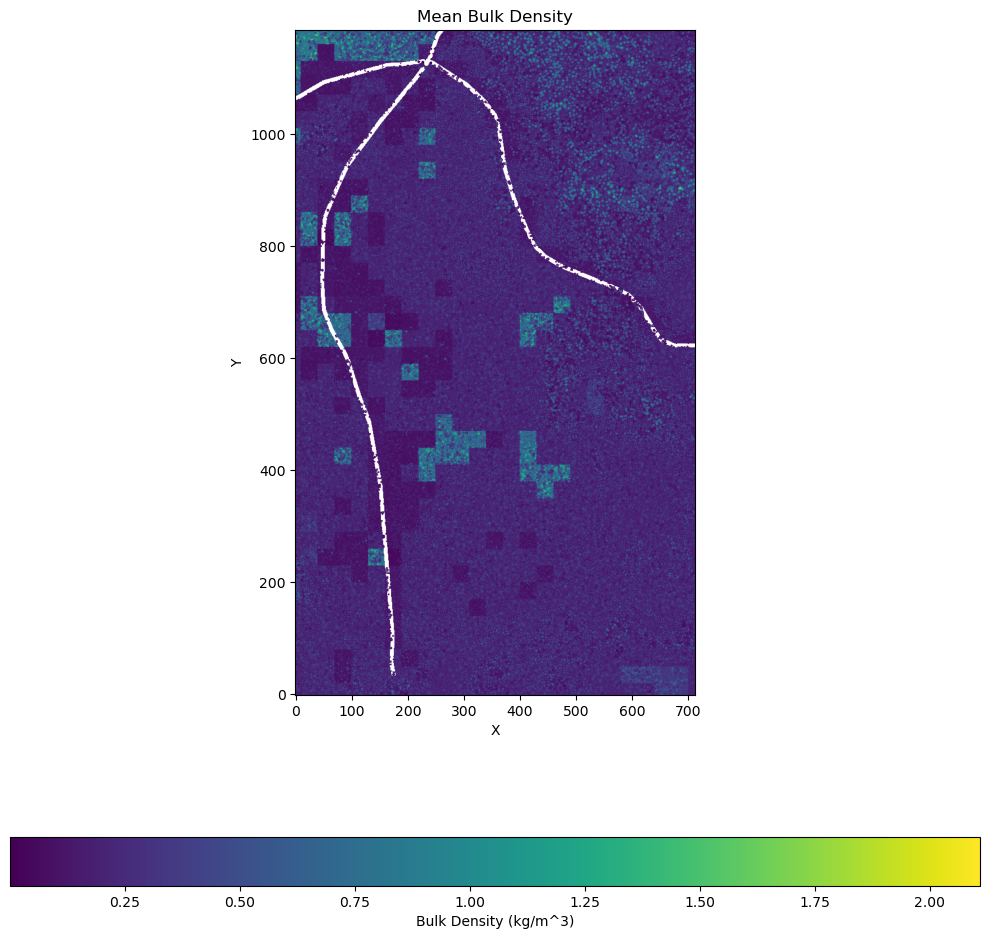

In [6]:


# Plot the bulk density grid summed across the z-axis
data = new_bulk_density
masked_data = np.ma.masked_equal(data, 0) # Mask all zeros

current_cmap = copy.copy(plt.cm.viridis)
current_cmap.set_bad(color='white')


fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(masked_data.mean(axis=0), cmap=current_cmap, origin = 'lower')
ax.set_title("Mean Bulk Density")
ax.set_xlabel("X")
ax.set_ylabel("Y")
fig.colorbar(im, ax=ax, label="Bulk Density (kg/m^3)", orientation="horizontal")
plt.tight_layout()
plt.show()



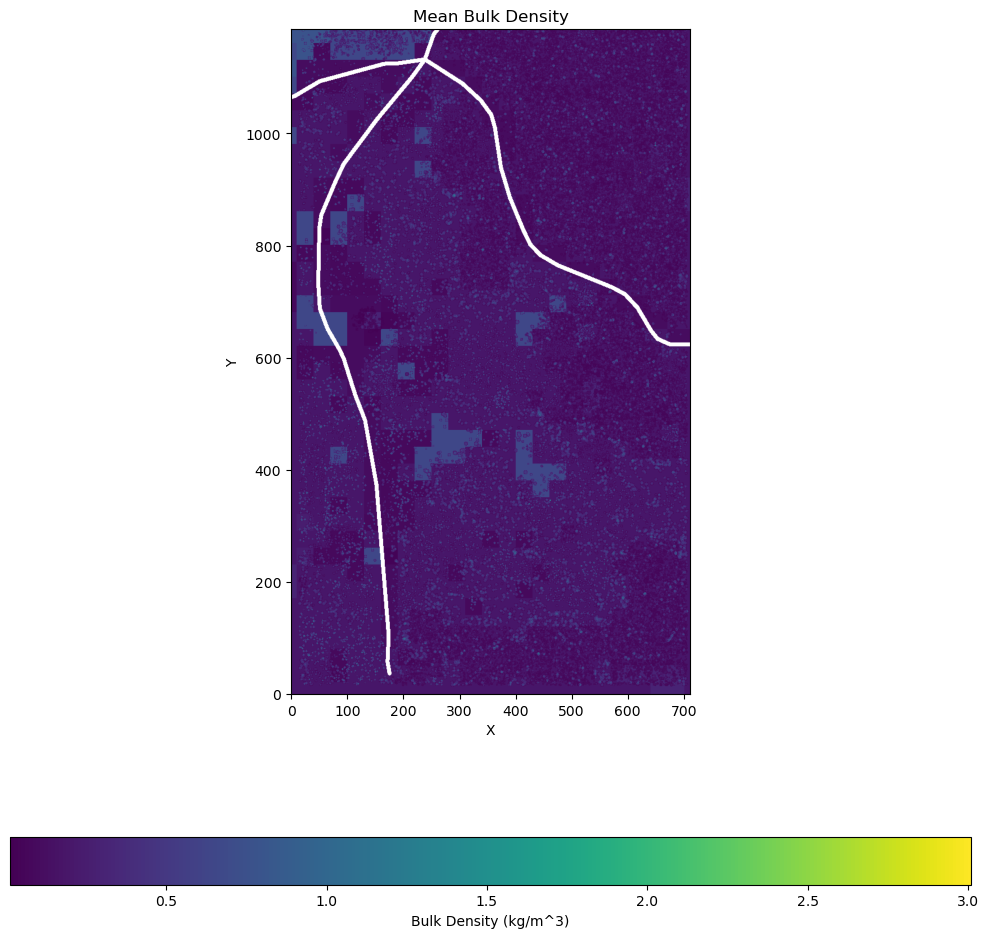

In [7]:


# Plot the bulk density grid summed across the z-axis
data = treemap_bulk_density
masked_data = np.ma.masked_equal(data, 0) # Mask all zeros

current_cmap = copy.copy(plt.cm.viridis)
current_cmap.set_bad(color='white')


fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(masked_data.mean(axis=0), cmap=current_cmap, origin = 'lower')
ax.set_title("Mean Bulk Density")
ax.set_xlabel("X")
ax.set_ylabel("Y")
fig.colorbar(im, ax=ax, label="Bulk Density (kg/m^3)", orientation="horizontal")
plt.tight_layout()
plt.show()



In [8]:
# differences in the two 
diff = treemap_bulk_density.sum(axis=0) - (new_bulk_density.sum(axis=0))

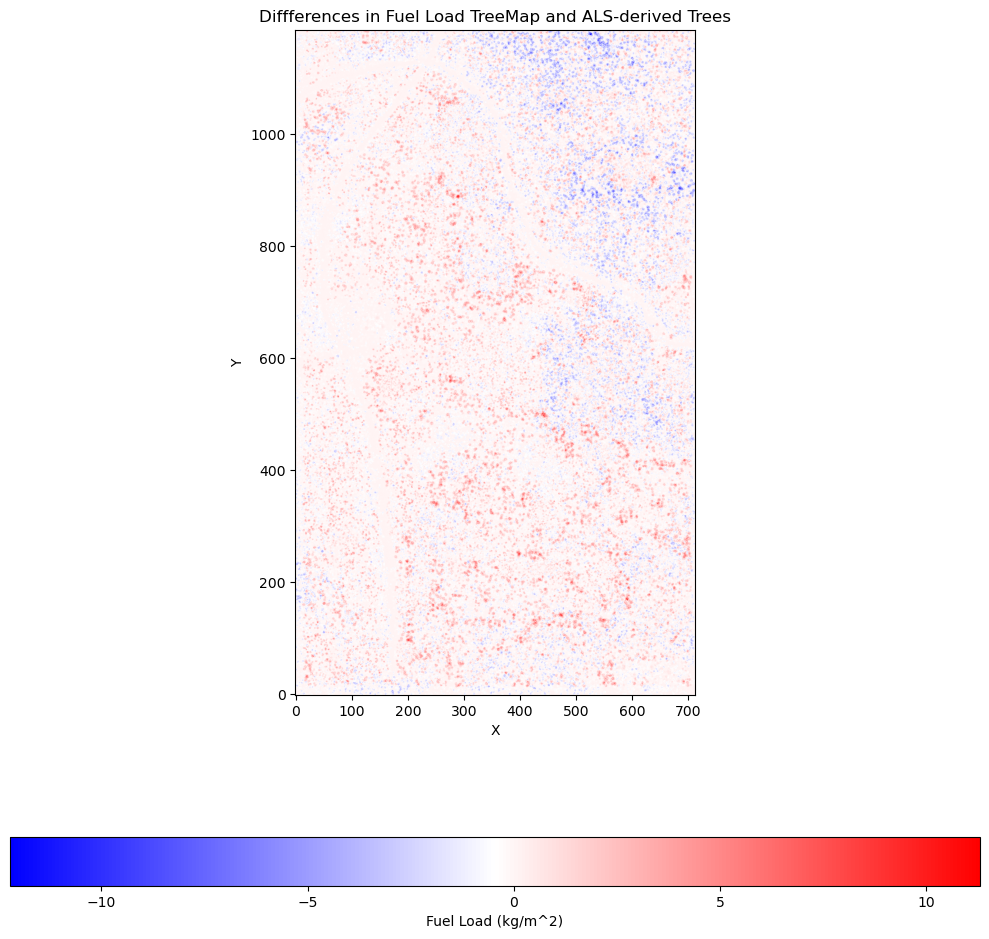

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(diff, cmap='bwr', origin = 'lower')
ax.set_title("Diffferences in Fuel Load TreeMap and ALS-derived Trees")
ax.set_xlabel("X")
ax.set_ylabel("Y")
fig.colorbar(im, ax=ax, label="Fuel Load (kg/m^2)", orientation="horizontal")
plt.tight_layout()
plt.show()

Blue is where TreeMap shows a higher bulk density, red is where ALS-derived Trees has a higher bulk density

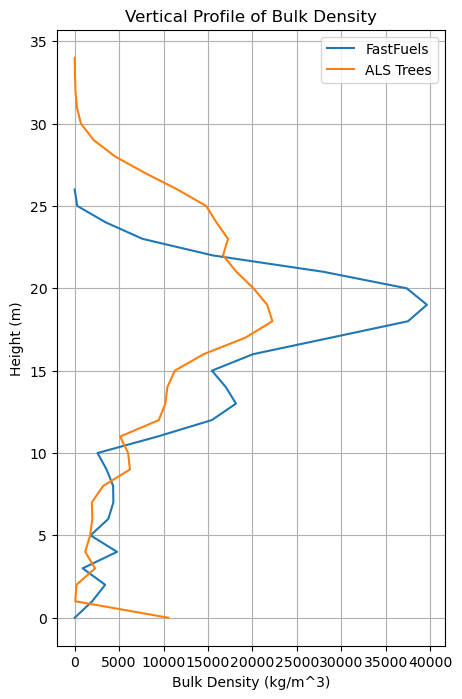

In [10]:


# Sum across the last two axes (rows and columns) to get 1 value per height layer
profile_values_tm = treemap_bulk_density[1:,:,:].sum(axis=(1, 2)) 
profile_values_als = new_bulk_density[1:,:,:].sum(axis=(1, 2)) 

# Create height indices
heights_tm = np.arange(profile_values_tm.shape[0])
heights_als = np.arange(profile_values_als.shape[0])

# Plotting
plt.figure(figsize=(5, 8))
plt.plot(profile_values_tm, heights_tm, linestyle='-', label = 'FastFuels')
plt.plot(profile_values_als, heights_als, linestyle='-', label = 'ALS Trees')

# Add labels for clarity
plt.xlabel('Bulk Density (kg/m^3)')
plt.ylabel('Height (m)')
plt.title('Vertical Profile of Bulk Density')
plt.grid(True)
plt.legend()
plt.show()



In [11]:


treemap_voxel_mass_kg = float(treemap_bulk_density.sum()) 

als_voxel_mass_kg = float(new_bulk_density.sum()) 

# Comparison
diff = treemap_voxel_mass_kg - als_voxel_mass_kg
pct = 100.0 * diff / treemap_voxel_mass_kg


print(f"ALS-derived trees voxel mass: {als_voxel_mass_kg:,.2f} kg")
print(f"TreeMap voxel mass: {treemap_voxel_mass_kg:,.2f} kg")
print(f"Difference (TreeMap - ALS): {diff:,.2f} kg ({pct:.4f}% difference)")



ALS-derived trees voxel mass: 539,399.25 kg
TreeMap voxel mass: 494,944.75 kg
Difference (TreeMap - ALS): -44,454.50 kg (-8.9817% difference)
